In [2]:
import cv2
import numpy as np
from PIL import Image

import os
import matplotlib.pyplot as plt

from skimage.feature import peak_local_max
from skimage.morphology import watershed

from scipy import ndimage

## 2 - Estimate the number of objects on the images

In [3]:
working_dir = 'count/'
files = next(os.walk(working_dir))[2]

In [4]:
images = []
for file in files:
     #read images from data folder
    img = cv2.imread(os.path.join(working_dir, file))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    images.append(img)

In [14]:
def visualize(images, numbers):
    for img, number in zip(images, numbers):
        plt.figure(figsize=(15, 15))
        plt.imshow(img, cmap='gray')
        plt.title('Number of objects - {}'.format(number))
        plt.axis('off')

In [6]:
def img_fill(im_in):  

    # Copy the thresholded image.
    im_floodfill = im_in.copy()

    # Mask used to flood filling.
    # Notice the size needs to be 2 pixels than the image.
    h, w = im_in.shape[:2]
    mask = np.zeros((h+2, w+2), np.uint8)

    # Floodfill from point (0, 0)
    cv2.floodFill(im_floodfill, mask, (0, 0), 0)
    cv2.floodFill(im_floodfill, mask, (w-1, 0), 0)
    cv2.floodFill(im_floodfill, mask, (w-1, h-1), 0)
    cv2.floodFill(im_floodfill, mask, (0, h-1), 0)

    # Invert floodfilled image
    im_floodfill_inv = cv2.bitwise_not(im_floodfill)
    
    # Combine the two images to get the foreground.
    fill_image = im_in | im_floodfill_inv
    
    return im_floodfill

def count_objects(img):
    
    # to grayscale and equalize distribution of intensities
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    gray = cv2.equalizeHist(gray)

    # perform cleaning and thresholding
    gray = cv2.medianBlur(gray, 3)
    gray = cv2.adaptiveThreshold(gray, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY, 13, 13)

    # post processing
    gray = cv2.GaussianBlur(gray, (3, 3), 1)
    _, gray = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    
    # perform morfological separation of objects
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
    gray = cv2.morphologyEx(gray, cv2.MORPH_OPEN, kernel, iterations=1)

    # post processing again
    gray = cv2.GaussianBlur(gray, (3, 3), 1)
    gray = cv2.fastNlMeansDenoising(gray, None, 70, 15, 15)
    _, gray = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    
    # delete background
    gray = img_fill(gray)
    
    # if objects concentrate in the small area of image, perform 
    # morphological opening with smaller kernel
    if gray.sum() / (gray.size * 255.0) < 0.16:
        kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3, 3))
        gray = cv2.morphologyEx(gray, cv2.MORPH_OPEN, kernel, iterations=3)

    # additional processing for very small objects
    if gray.sum() / (gray.size * 255.0) < 0.05:
        kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (4, 4))
        gray = cv2.morphologyEx(gray, cv2.MORPH_OPEN, kernel, iterations=3)

    # distance transform between separated objects
    dist_transform = ndimage.morphology.distance_transform_edt(gray)

    # empirical estimation of min_distance
    min_distance = int(np.quantile(dist_transform[dist_transform > 0], 0.97))
    
    localMax = peak_local_max(dist_transform, indices=False, 
                              min_distance=min_distance, labels=gray)

    markers = ndimage.label(localMax)[0] 
    labels = watershed(-dist_transform, markers, mask=gray)
    
    # overall number of classes minus background
    count = len(np.unique(labels)) - 1
    
    return count

In [10]:
total = list(map(lambda x: count_objects(x), images))

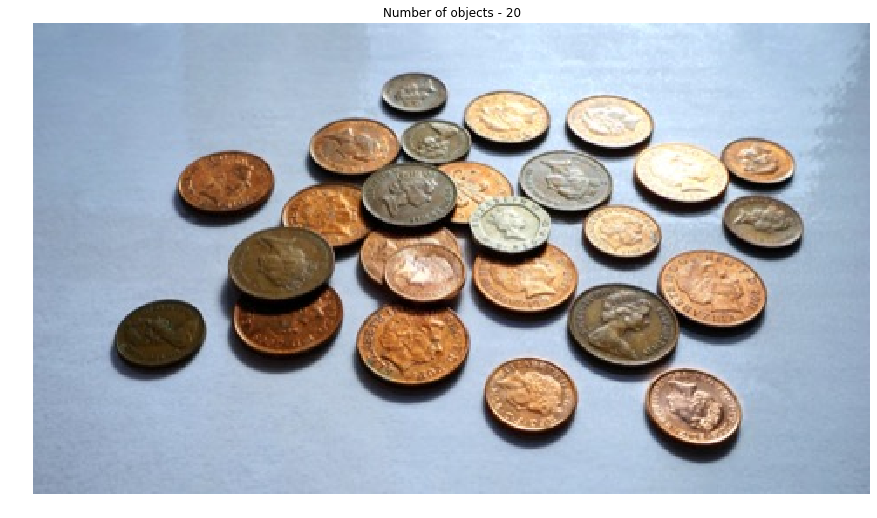

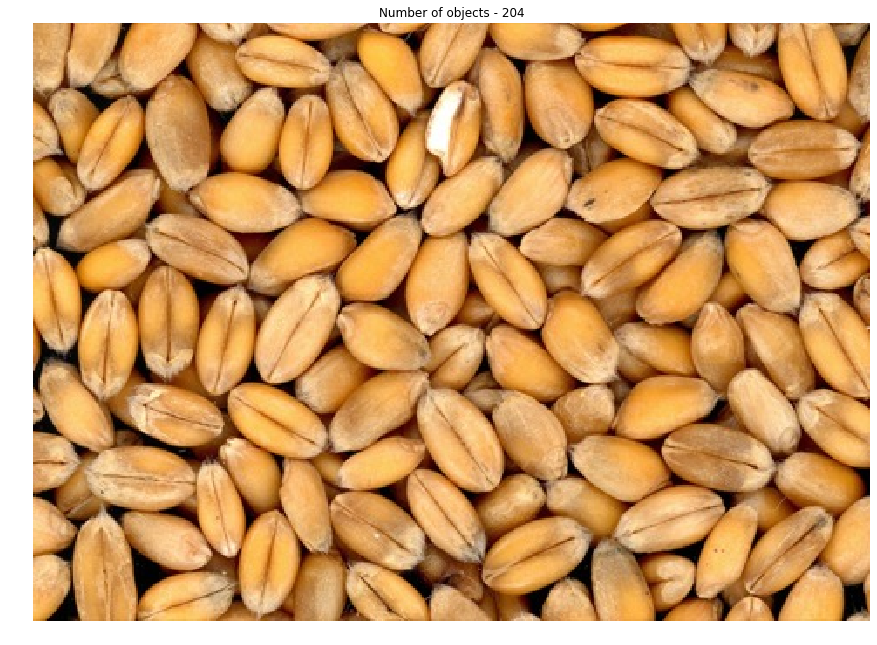

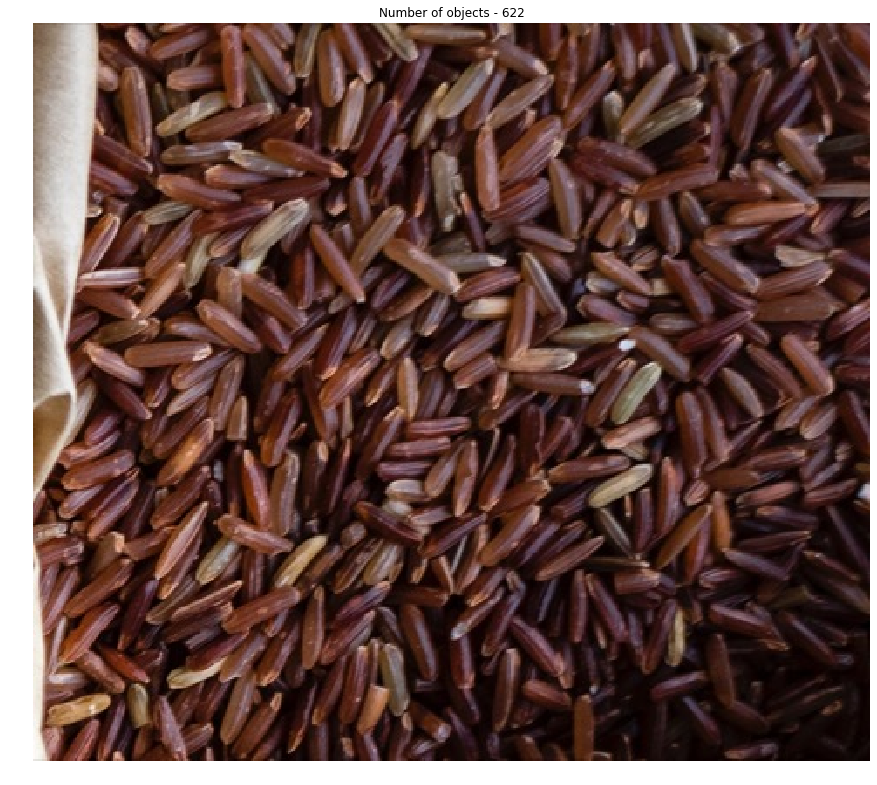

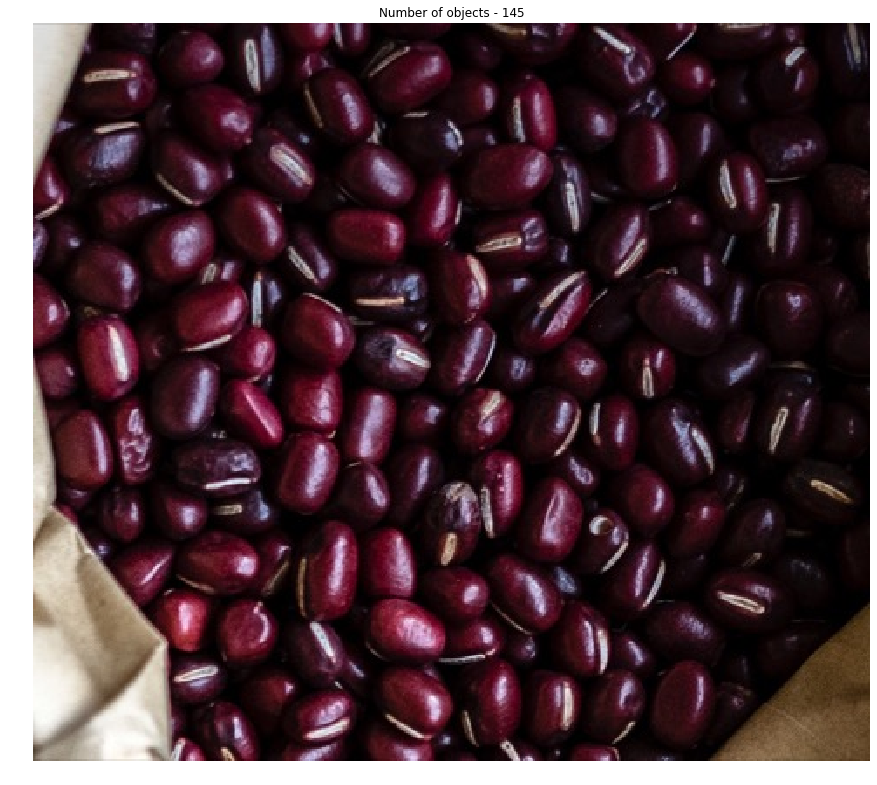

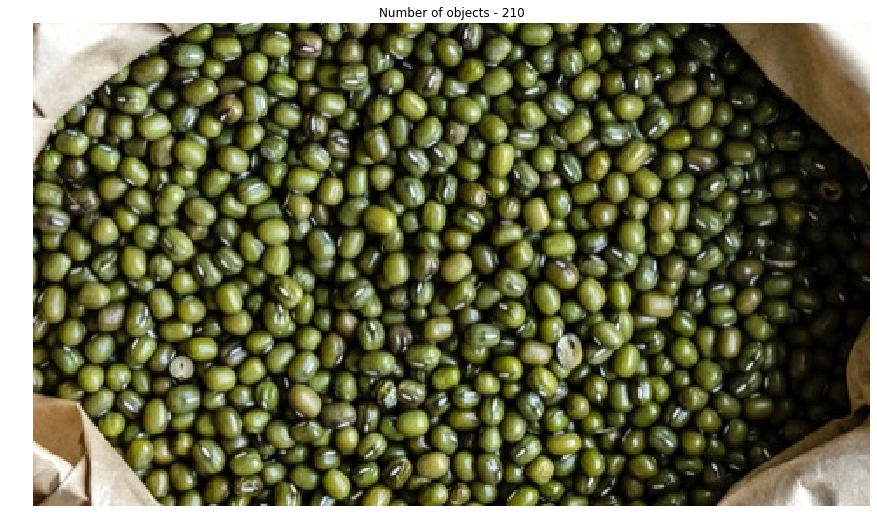

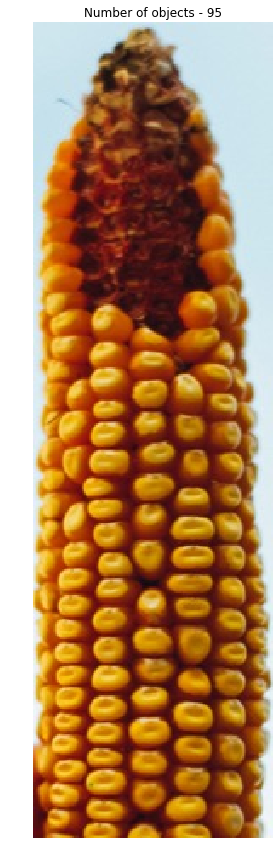

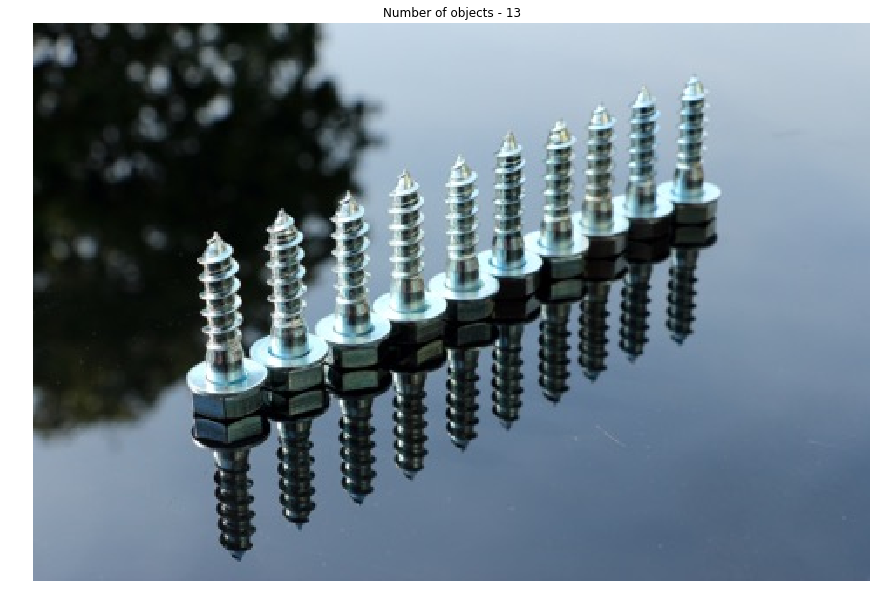

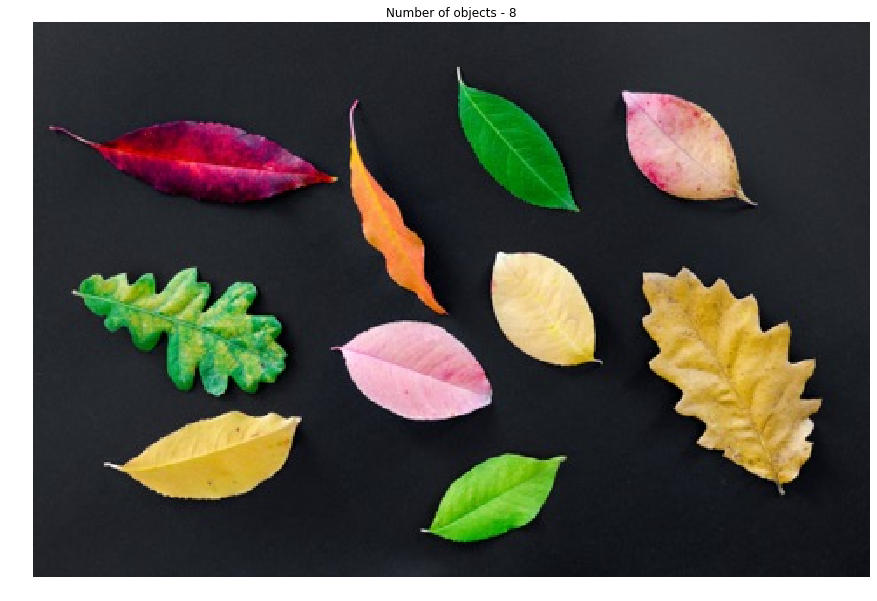

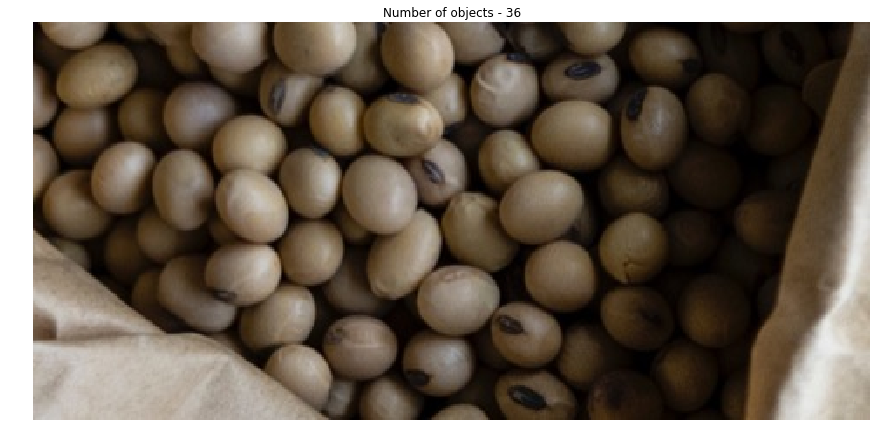

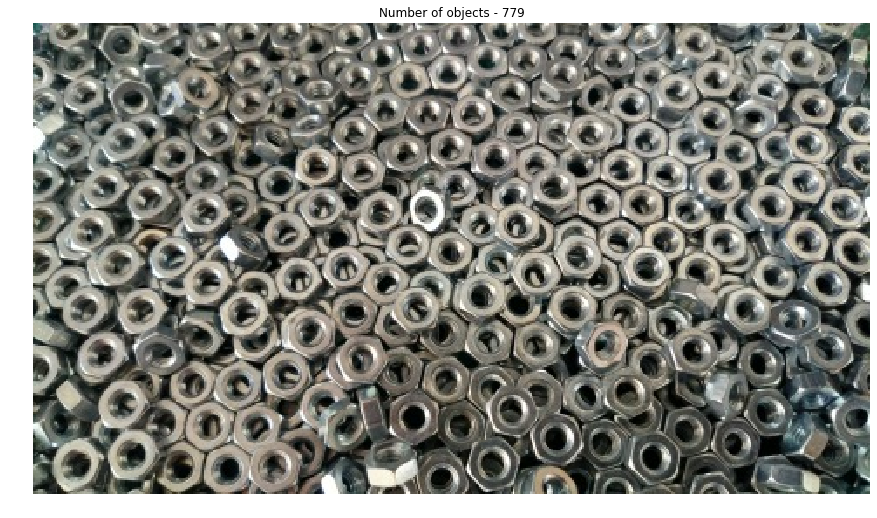

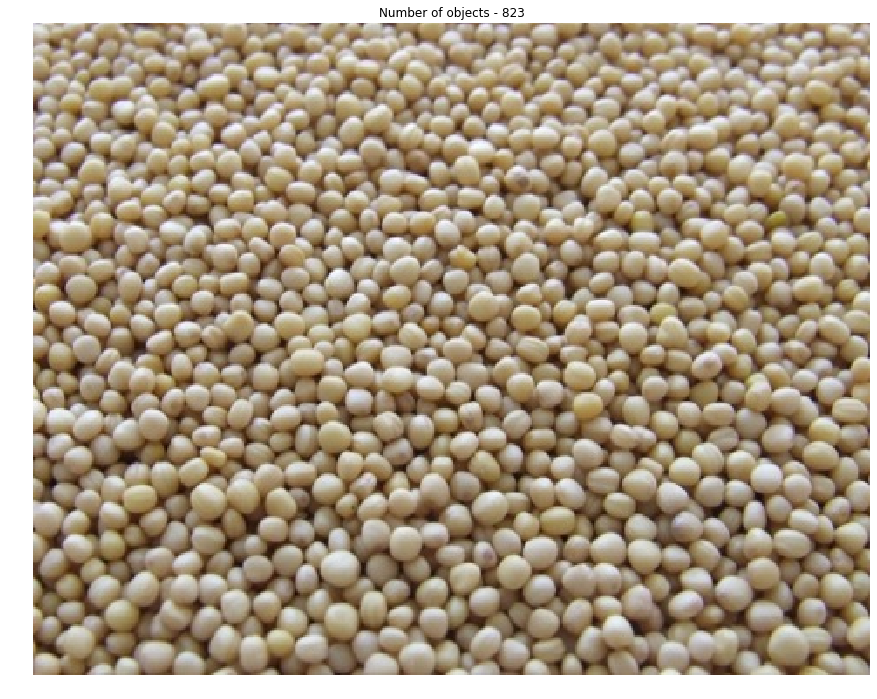

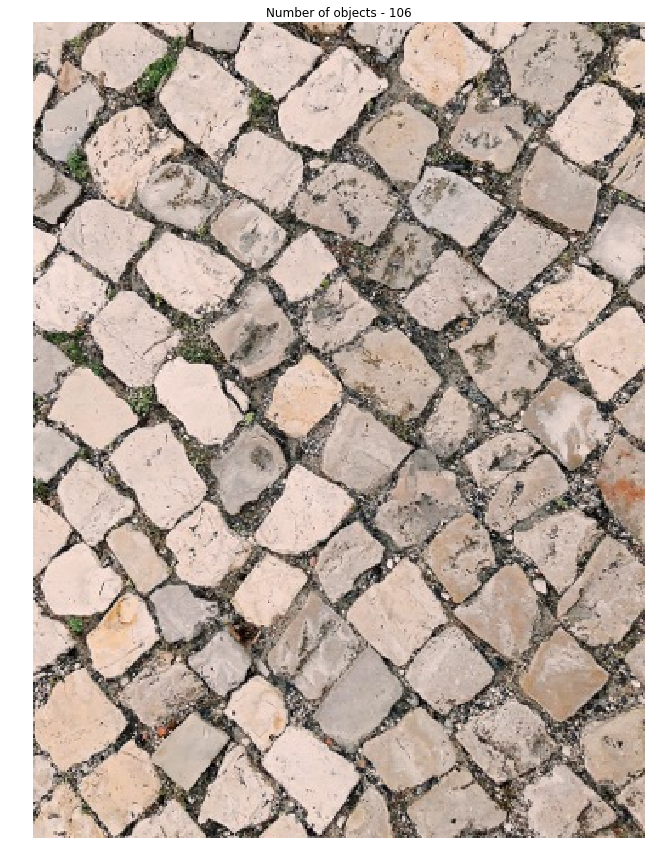

In [15]:
visualize(images, total)